In [1]:
%%writefile requirements.txt
matplotlib
numpy
gymnasium
stable-baselines3
torch
tensorboard

Overwriting requirements.txt


In [2]:
!/Users/br4c3/Projects/aitopgun-rl/.venv/bin/python3 -m pip install --upgrade pip
!pip3 install -r requirements.txt
!mkdir -p src

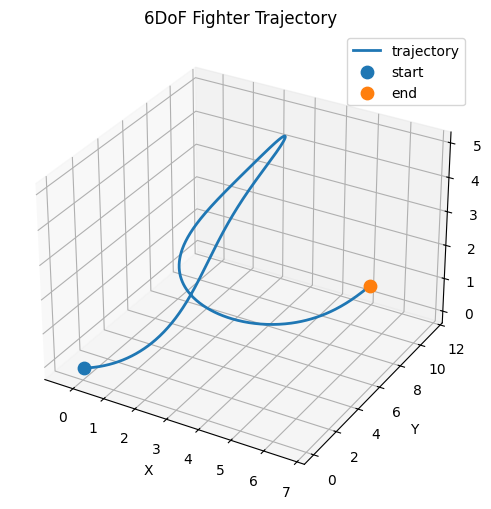

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# Rotation Matrix
def rotation_matrix(roll, pitch, yaw):

    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)

    Rz = np.array([
        [cy, -sy, 0],
        [sy,  cy, 0],
        [0,    0, 1]
    ])

    Ry = np.array([
        [cp, 0, sp],
        [0,  1, 0],
        [-sp,0, cp]
    ])

    Rx = np.array([
        [1, 0, 0],
        [0, cr, -sr],
        [0, sr,  cr]
    ])

    return Rz @ Ry @ Rx


# =========================
# Fighter Geometry
# =========================
fighter_points = np.array([
    [ 2.0,  0.0,  0.0],   # nose
    [-1.0, -0.8,  0.0],   # left wing
    [-1.0,  0.8,  0.0],   # right wing
    [-1.5,  0.0,  0.5],   # tail
])

fighter_edges = [
    (0,1),
    (0,2),
    (1,2),
    (0,3),
]


# =========================
# Initial State
# =========================
pos = np.array([0.0, 0.0, 0.0])

roll = 0.0
pitch = 0.0
yaw = 0.0

speed = 0.5

dt = 0.05
steps = 800

trajectory = []


# =========================
# Simple 6DoF Simulation
# =========================
for i in range(steps):

    # angular motion
    roll += 0.01
    pitch = 0.2 * np.sin(i * 0.02)
    yaw += 0.008

    # rotation
    R = rotation_matrix(roll, pitch, yaw)

    # body forward direction
    forward = R @ np.array([1,1,0])

    # update position
    pos += forward * speed * dt

    trajectory.append(pos.copy())


trajectory = np.array(trajectory)


# =========================
# Final Aircraft Pose
# =========================
transformed = (R @ fighter_points.T).T + pos


# =========================
# Plot
# =========================
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# trajectory
ax.plot(
    trajectory[:,0],
    trajectory[:,1],
    trajectory[:,2],
    linewidth=2,
    label="trajectory"
)

ax.scatter(
    trajectory[0,0],
    trajectory[0,1],
    trajectory[0,2],
    s=80,
    label="start"
)

ax.scatter(
    trajectory[-1,0],
    trajectory[-1,1],
    trajectory[-1,2],
    s=80,
    label="end"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("6DoF Fighter Trajectory")

ax.legend()

plt.show()

In [4]:
%%writefile src/fighter_env.py
from __future__ import annotations

import numpy as np
import gymnasium as gym
from gymnasium import spaces


class SimpleFighterEnergyEnv(gym.Env):
    """
    Simple 3D fighter-like environment for SAC.

    Observation:
        pos(3), vel(3), rpy(3), target_rel(3), speed(1), energy(1)

    Action:
        roll_rate, pitch_rate, yaw_rate, thrust
    """

    metadata = {"render_modes": []}

    def __init__(self):
        super().__init__()

        self.dt = 0.05
        self.max_steps = 600
        self.g = 9.81

        self.target = np.array([80.0, 40.0, 25.0], dtype=np.float32)

        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0, -1.0, 0.0], dtype=np.float32),
            high=np.array([ 1.0,  1.0,  1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(14,),
            dtype=np.float32,
        )

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.pos = np.array([0.0, 0.0, 20.0], dtype=np.float32)
        self.vel = np.array([20.0, 0.0, 0.0], dtype=np.float32)

        self.roll = 0.0
        self.pitch = 0.0
        self.yaw = 0.0

        self.step_count = 0
        self.prev_dist = np.linalg.norm(self.target - self.pos)

        return self._get_obs(), {}

    def _rotation_matrix(self):
        cr, sr = np.cos(self.roll), np.sin(self.roll)
        cp, sp = np.cos(self.pitch), np.sin(self.pitch)
        cy, sy = np.cos(self.yaw), np.sin(self.yaw)

        Rz = np.array([
            [cy, -sy, 0.0],
            [sy,  cy, 0.0],
            [0.0, 0.0, 1.0],
        ])

        Ry = np.array([
            [cp, 0.0, sp],
            [0.0, 1.0, 0.0],
            [-sp, 0.0, cp],
        ])

        Rx = np.array([
            [1.0, 0.0, 0.0],
            [0.0, cr, -sr],
            [0.0, sr,  cr],
        ])

        return Rz @ Ry @ Rx

    def _energy(self):
        speed = np.linalg.norm(self.vel)
        height = max(float(self.pos[2]), 0.0)

        # mass is omitted because it is constant
        potential = self.g * height
        kinetic = 0.5 * speed ** 2

        return potential + kinetic

    def _get_obs(self):
        speed = np.linalg.norm(self.vel)
        energy = self._energy()
        target_rel = self.target - self.pos

        obs = np.concatenate([
            self.pos,
            self.vel,
            np.array([self.roll, self.pitch, self.yaw], dtype=np.float32),
            target_rel,
            np.array([speed, energy], dtype=np.float32),
        ])

        return obs.astype(np.float32)

    def step(self, action):
        action = np.asarray(action, dtype=np.float32)

        roll_rate, pitch_rate, yaw_rate, thrust = action

        prev_dist = np.linalg.norm(self.target - self.pos)

        # attitude update
        self.roll += float(roll_rate) * self.dt
        self.pitch += float(pitch_rate) * self.dt
        self.yaw += float(yaw_rate) * self.dt

        self.roll = np.clip(self.roll, -1.2, 1.2)
        self.pitch = np.clip(self.pitch, -0.8, 0.8)

        R = self._rotation_matrix()
        forward = R @ np.array([1.0, 0.0, 0.0])

        speed = np.linalg.norm(self.vel)

        # simple dynamics
        thrust_accel = forward * float(thrust) * 35.0
        gravity = np.array([0.0, 0.0, -self.g])
        drag = -0.015 * self.vel * speed

        accel = thrust_accel + gravity + drag

        self.vel = self.vel + accel * self.dt
        self.pos = self.pos + self.vel * self.dt

        self.step_count += 1

        dist = np.linalg.norm(self.target - self.pos)
        progress = prev_dist - dist

        speed = np.linalg.norm(self.vel)
        height = float(self.pos[2])
        energy = self._energy()

        action_cost = np.sum(np.square(action))

        reward = 0.0

        # main objective
        reward += 3.0 * progress
        reward -= 0.015 * dist

        # energy advantage
        reward += 0.0015 * energy

        # penalties
        reward -= 0.002 * action_cost
        reward -= 0.002 * float(thrust) ** 2

        terminated = False
        truncated = False

        if dist < 5.0:
            reward += 200.0
            terminated = True

        if height < 0.0:
            reward -= 200.0
            terminated = True

        if speed < 5.0:
            reward -= 10.0

        if speed > 120.0:
            reward -= 50.0
            terminated = True

        if self.step_count >= self.max_steps:
            truncated = True

        info = {
            "dist": dist,
            "speed": speed,
            "height": height,
            "energy": energy,
            "progress": progress,
        }

        return self._get_obs(), float(reward), terminated, truncated, info

Overwriting src/fighter_env.py


In [5]:
from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from src.fighter_env import SimpleFighterEnergyEnv

env = SimpleFighterEnergyEnv()
env = Monitor(env)

model = SAC(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    buffer_size=200_000,
    learning_starts=5_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",
    tensorboard_log="logs/sac_fighter_energy",
)

model.learn(total_timesteps=300_000)

model.save("models/sac_fighter_energy")

Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to logs/sac_fighter_energy/SAC_2
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 47.2     |
|    ep_rew_mean     | -93      |
| time/              |          |
|    episodes        | 4        |
|    fps             | 9197     |
|    time_elapsed    | 0        |
|    total_timesteps | 189      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 46.6     |
|    ep_rew_mean     | -89.5    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 10158    |
|    time_elapsed    | 0        |
|    total_timesteps | 373      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 45.5     |
|    ep_rew_mean     | -90.3    |
| time/              |          |
|    episodes        | 12       |
|    fps             | 

/Users/br4c3/Projects/aitopgun-rl/.venv/lib/python3.10/site-packages/stable_baselines3/common/save_util.py:284: UserWarning: Path 'models' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


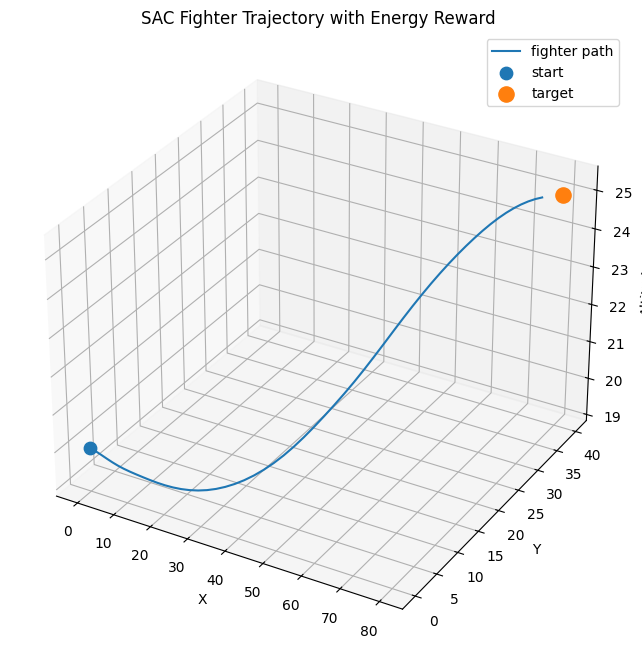

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import SAC
from src.fighter_env import SimpleFighterEnergyEnv


env = SimpleFighterEnergyEnv()
model = SAC.load("models/sac_fighter_energy")

obs, _ = env.reset()

traj = []
speeds = []
heights = []
energies = []
dists = []

for _ in range(env.max_steps):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    traj.append(env.pos.copy())
    speeds.append(info["speed"])
    heights.append(info["height"])
    energies.append(info["energy"])
    dists.append(info["dist"])

    if terminated or truncated:
        break

traj = np.array(traj)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], label="fighter path")
ax.scatter(0, 0, 20, s=80, label="start")
ax.scatter(env.target[0], env.target[1], env.target[2], s=120, label="target")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Altitude")
ax.set_title("SAC Fighter Trajectory with Energy Reward")
ax.legend()

plt.show()

### MASAC

In [7]:
%%writefile src/ma_fighter_env.py
import numpy as np


class MultiAgentFighterEnv:
    def __init__(self):
        self.n_agents = 2
        self.dt = 0.05
        self.max_steps = 600
        self.g = 9.81

        self.obs_dim = 17
        self.act_dim = 4

        self.step_count = 0
        self.reset()

    def reset(self):
        self.pos = np.array([
            [0.0, 0.0, 25.0],
            [80.0, 40.0, 25.0],
        ], dtype=np.float32)

        self.vel = np.array([
            [25.0, 0.0, 0.0],
            [-25.0, 0.0, 0.0],
        ], dtype=np.float32)

        self.rpy = np.array([
            [0.0, 0.0, 0.0],
            [0.0, 0.0, np.pi],
        ], dtype=np.float32)

        self.step_count = 0
        return self._get_obs()

    def _rotation_matrix(self, roll, pitch, yaw):
        cr, sr = np.cos(roll), np.sin(roll)
        cp, sp = np.cos(pitch), np.sin(pitch)
        cy, sy = np.cos(yaw), np.sin(yaw)

        Rz = np.array([
            [cy, -sy, 0.0],
            [sy,  cy, 0.0],
            [0.0, 0.0, 1.0],
        ])

        Ry = np.array([
            [cp, 0.0, sp],
            [0.0, 1.0, 0.0],
            [-sp, 0.0, cp],
        ])

        Rx = np.array([
            [1.0, 0.0, 0.0],
            [0.0, cr, -sr],
            [0.0, sr,  cr],
        ])

        return Rz @ Ry @ Rx

    def _energy(self, i):
        speed = np.linalg.norm(self.vel[i])
        height = max(float(self.pos[i, 2]), 0.0)
        return self.g * height + 0.5 * speed ** 2

    def _get_obs(self):
        obs = []

        for i in range(self.n_agents):
            j = 1 - i

            rel_pos = self.pos[j] - self.pos[i]
            rel_vel = self.vel[j] - self.vel[i]

            speed = np.linalg.norm(self.vel[i])
            energy = self._energy(i)

            o = np.concatenate([
                self.pos[i],
                self.vel[i],
                self.rpy[i],
                rel_pos,
                rel_vel,
                np.array([speed, energy], dtype=np.float32),
            ])

            obs.append(o.astype(np.float32))

        return obs

    def step(self, actions):
        actions = np.asarray(actions, dtype=np.float32)

        prev_dist = np.linalg.norm(self.pos[0] - self.pos[1])

        for i in range(self.n_agents):
            roll_rate, pitch_rate, yaw_rate, thrust = actions[i]

            self.rpy[i, 0] += roll_rate * self.dt
            self.rpy[i, 1] += pitch_rate * self.dt
            self.rpy[i, 2] += yaw_rate * self.dt

            self.rpy[i, 0] = np.clip(self.rpy[i, 0], -1.2, 1.2)
            self.rpy[i, 1] = np.clip(self.rpy[i, 1], -0.8, 0.8)

            R = self._rotation_matrix(*self.rpy[i])
            forward = R @ np.array([1.0, 0.0, 0.0])

            speed = np.linalg.norm(self.vel[i])

            thrust_accel = forward * thrust * 35.0
            gravity = np.array([0.0, 0.0, -self.g])
            drag = -0.015 * self.vel[i] * speed

            accel = thrust_accel + gravity + drag

            self.vel[i] += accel * self.dt
            self.pos[i] += self.vel[i] * self.dt

        self.step_count += 1

        dist = np.linalg.norm(self.pos[0] - self.pos[1])
        closing = prev_dist - dist

        rewards = []

        for i in range(self.n_agents):
            j = 1 - i

            my_energy = self._energy(i)
            enemy_energy = self._energy(j)
            speed = np.linalg.norm(self.vel[i])
            height = self.pos[i, 2]

            energy_adv = my_energy - enemy_energy
            action_cost = np.sum(actions[i] ** 2)

            reward = 0.0

            # 상대에게 접근
            reward += 1.5 * closing

            # 에너지 우위
            reward += 0.001 * energy_adv

            # 너무 멀면 패널티
            reward -= 0.005 * dist

            # 조작 비용
            reward -= 0.002 * action_cost

            # 생존 조건
            if height < 0.0:
                reward -= 200.0

            if speed < 5.0:
                reward -= 10.0

            if speed > 130.0:
                reward -= 30.0

            rewards.append(float(reward))

        done = False

        if self.step_count >= self.max_steps:
            done = True

        if np.any(self.pos[:, 2] < 0.0):
            done = True

        obs = self._get_obs()

        info = {
            "dist": dist,
            "energy_0": self._energy(0),
            "energy_1": self._energy(1),
            "pos": self.pos.copy(),
        }

        return obs, rewards, done, info

Writing src/ma_fighter_env.py


In [8]:
%%writefile src/masac.py
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


LOG_STD_MIN = -20
LOG_STD_MAX = 2


class ReplayBuffer:
    def __init__(self, capacity, n_agents, obs_dim, act_dim):
        self.capacity = capacity
        self.n_agents = n_agents
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.ptr = 0
        self.size = 0

        self.obs = np.zeros((capacity, n_agents, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, n_agents, act_dim), dtype=np.float32)
        self.rewards = np.zeros((capacity, n_agents), dtype=np.float32)
        self.next_obs = np.zeros((capacity, n_agents, obs_dim), dtype=np.float32)
        self.done = np.zeros((capacity, 1), dtype=np.float32)

    def push(self, obs, actions, rewards, next_obs, done):
        self.obs[self.ptr] = np.asarray(obs, dtype=np.float32)
        self.actions[self.ptr] = np.asarray(actions, dtype=np.float32)
        self.rewards[self.ptr] = np.asarray(rewards, dtype=np.float32)
        self.next_obs[self.ptr] = np.asarray(next_obs, dtype=np.float32)
        self.done[self.ptr] = float(done)

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size, device):
        idx = np.random.randint(0, self.size, size=batch_size)

        return (
            torch.tensor(self.obs[idx], device=device),
            torch.tensor(self.actions[idx], device=device),
            torch.tensor(self.rewards[idx], device=device),
            torch.tensor(self.next_obs[idx], device=device),
            torch.tensor(self.done[idx], device=device),
        )


class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=256):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.mean = nn.Linear(hidden_dim, act_dim)
        self.log_std = nn.Linear(hidden_dim, act_dim)

    def forward(self, obs):
        x = self.net(obs)
        mean = self.mean(x)
        log_std = self.log_std(x)
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)
        return mean, log_std

    def sample(self, obs):
        mean, log_std = self(obs)
        std = log_std.exp()

        normal = torch.distributions.Normal(mean, std)
        z = normal.rsample()

        action = torch.tanh(z)

        log_prob = normal.log_prob(z)
        log_prob -= torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)

        # action range:
        # raw tanh: [-1, 1]
        # thrust should be [0, 1]
        action_scaled = action.clone()
        action_scaled[:, 3] = (action_scaled[:, 3] + 1.0) / 2.0

        return action_scaled, log_prob


class Critic(nn.Module):
    def __init__(self, global_obs_dim, global_act_dim, hidden_dim=256):
        super().__init__()

        self.q = nn.Sequential(
            nn.Linear(global_obs_dim + global_act_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, global_obs, global_action):
        x = torch.cat([global_obs, global_action], dim=-1)
        return self.q(x)


class MASAC:
    def __init__(
        self,
        n_agents,
        obs_dim,
        act_dim,
        device="cpu",
        gamma=0.99,
        tau=0.005,
        alpha=0.2,
        lr=3e-4,
    ):
        self.n_agents = n_agents
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.device = device

        self.gamma = gamma
        self.tau = tau
        self.alpha = alpha

        self.global_obs_dim = n_agents * obs_dim
        self.global_act_dim = n_agents * act_dim

        self.actors = nn.ModuleList([
            Actor(obs_dim, act_dim).to(device)
            for _ in range(n_agents)
        ])

        self.critics1 = nn.ModuleList([
            Critic(self.global_obs_dim, self.global_act_dim).to(device)
            for _ in range(n_agents)
        ])

        self.critics2 = nn.ModuleList([
            Critic(self.global_obs_dim, self.global_act_dim).to(device)
            for _ in range(n_agents)
        ])

        self.target_critics1 = nn.ModuleList([
            Critic(self.global_obs_dim, self.global_act_dim).to(device)
            for _ in range(n_agents)
        ])

        self.target_critics2 = nn.ModuleList([
            Critic(self.global_obs_dim, self.global_act_dim).to(device)
            for _ in range(n_agents)
        ])

        for i in range(n_agents):
            self.target_critics1[i].load_state_dict(self.critics1[i].state_dict())
            self.target_critics2[i].load_state_dict(self.critics2[i].state_dict())

        self.actor_opts = [
            torch.optim.Adam(self.actors[i].parameters(), lr=lr)
            for i in range(n_agents)
        ]

        self.critic1_opts = [
            torch.optim.Adam(self.critics1[i].parameters(), lr=lr)
            for i in range(n_agents)
        ]

        self.critic2_opts = [
            torch.optim.Adam(self.critics2[i].parameters(), lr=lr)
            for i in range(n_agents)
        ]

    @torch.no_grad()
    def act(self, obs, deterministic=False):
        actions = []

        for i in range(self.n_agents):
            o = torch.tensor(obs[i], dtype=torch.float32, device=self.device).unsqueeze(0)

            if deterministic:
                mean, _ = self.actors[i](o)
                a = torch.tanh(mean)
                a[:, 3] = (a[:, 3] + 1.0) / 2.0
            else:
                a, _ = self.actors[i].sample(o)

            actions.append(a.cpu().numpy()[0])

        return np.asarray(actions, dtype=np.float32)

    def update(self, replay, batch_size=256):
        obs, actions, rewards, next_obs, done = replay.sample(batch_size, self.device)

        global_obs = obs.reshape(batch_size, -1)
        global_actions = actions.reshape(batch_size, -1)
        global_next_obs = next_obs.reshape(batch_size, -1)

        losses = {}

        with torch.no_grad():
            next_actions = []
            next_log_probs = []

            for i in range(self.n_agents):
                a_i, logp_i = self.actors[i].sample(next_obs[:, i, :])
                next_actions.append(a_i)
                next_log_probs.append(logp_i)

            next_actions_cat = torch.cat(next_actions, dim=-1)

        for i in range(self.n_agents):
            with torch.no_grad():
                q1_next = self.target_critics1[i](global_next_obs, next_actions_cat)
                q2_next = self.target_critics2[i](global_next_obs, next_actions_cat)
                q_next = torch.min(q1_next, q2_next)

                target_q = rewards[:, i:i+1] + self.gamma * (1.0 - done) * (
                    q_next - self.alpha * next_log_probs[i]
                )

            q1 = self.critics1[i](global_obs, global_actions)
            q2 = self.critics2[i](global_obs, global_actions)

            critic1_loss = F.mse_loss(q1, target_q)
            critic2_loss = F.mse_loss(q2, target_q)

            self.critic1_opts[i].zero_grad()
            critic1_loss.backward()
            self.critic1_opts[i].step()

            self.critic2_opts[i].zero_grad()
            critic2_loss.backward()
            self.critic2_opts[i].step()

            # actor update
            new_actions = []
            log_probs = []

            for j in range(self.n_agents):
                a_j, logp_j = self.actors[j].sample(obs[:, j, :])

                if j != i:
                    a_j = a_j.detach()
                    logp_j = logp_j.detach()

                new_actions.append(a_j)
                log_probs.append(logp_j)

            new_actions_cat = torch.cat(new_actions, dim=-1)

            q1_pi = self.critics1[i](global_obs, new_actions_cat)
            q2_pi = self.critics2[i](global_obs, new_actions_cat)
            q_pi = torch.min(q1_pi, q2_pi)

            actor_loss = (self.alpha * log_probs[i] - q_pi).mean()

            self.actor_opts[i].zero_grad()
            actor_loss.backward()
            self.actor_opts[i].step()

            self._soft_update(self.critics1[i], self.target_critics1[i])
            self._soft_update(self.critics2[i], self.target_critics2[i])

            losses[f"agent_{i}_actor_loss"] = actor_loss.item()
            losses[f"agent_{i}_critic_loss"] = (critic1_loss.item() + critic2_loss.item()) / 2.0

        return losses

    def _soft_update(self, net, target_net):
        for p, tp in zip(net.parameters(), target_net.parameters()):
            tp.data.copy_(self.tau * p.data + (1.0 - self.tau) * tp.data)

    def save(self, path):
        torch.save({
            "actors": [a.state_dict() for a in self.actors],
            "critics1": [c.state_dict() for c in self.critics1],
            "critics2": [c.state_dict() for c in self.critics2],
        }, path)

    def load(self, path):
        ckpt = torch.load(path, map_location=self.device)

        for i in range(self.n_agents):
            self.actors[i].load_state_dict(ckpt["actors"][i])
            self.critics1[i].load_state_dict(ckpt["critics1"][i])
            self.critics2[i].load_state_dict(ckpt["critics2"][i])

Writing src/masac.py


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.ma_fighter_env import MultiAgentFighterEnv
from src.masac import MASAC, ReplayBuffer


device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

env = MultiAgentFighterEnv()

agent = MASAC(
    n_agents=env.n_agents,
    obs_dim=env.obs_dim,
    act_dim=env.act_dim,
    device=device,
    gamma=0.99,
    tau=0.005,
    alpha=0.2,
    lr=3e-4,
)

replay = ReplayBuffer(
    capacity=300_000,
    n_agents=env.n_agents,
    obs_dim=env.obs_dim,
    act_dim=env.act_dim,
)

total_steps = 200_000
start_steps = 5_000
batch_size = 256

episode_rewards = []
episode_reward = np.zeros(env.n_agents)

obs = env.reset()

for step in range(1, total_steps + 1):
    if step < start_steps:
        actions = np.zeros((env.n_agents, env.act_dim), dtype=np.float32)
        actions[:, :3] = np.random.uniform(-1, 1, size=(env.n_agents, 3))
        actions[:, 3] = np.random.uniform(0, 1, size=(env.n_agents,))
    else:
        actions = agent.act(obs, deterministic=False)

    next_obs, rewards, done, info = env.step(actions)

    replay.push(obs, actions, rewards, next_obs, done)

    episode_reward += np.array(rewards)
    obs = next_obs

    if replay.size >= batch_size and step >= start_steps:
        losses = agent.update(replay, batch_size=batch_size)

    if done:
        episode_rewards.append(episode_reward.copy())

        if len(episode_rewards) % 10 == 0:
            avg = np.mean(episode_rewards[-10:], axis=0)
            print(
                f"step={step} | "
                f"avg_reward_0={avg[0]:.2f} | "
                f"avg_reward_1={avg[1]:.2f} | "
                f"dist={info['dist']:.2f}"
            )

        obs = env.reset()
        episode_reward = np.zeros(env.n_agents)

agent.save("models/masac_fighter.pt")

device: cpu
step=562 | avg_reward_0=-112.32 | avg_reward_1=-174.20 | dist=78.89
step=1082 | avg_reward_0=-116.54 | avg_reward_1=-114.22 | dist=82.34
step=1613 | avg_reward_0=-141.57 | avg_reward_1=-101.86 | dist=94.52
step=2132 | avg_reward_0=-92.44 | avg_reward_1=-170.41 | dist=80.47
step=2652 | avg_reward_0=-112.84 | avg_reward_1=-113.22 | dist=76.30
step=3176 | avg_reward_0=-112.05 | avg_reward_1=-113.00 | dist=73.05
step=3710 | avg_reward_0=-138.30 | avg_reward_1=-117.42 | dist=87.77
step=4237 | avg_reward_0=-136.51 | avg_reward_1=-96.81 | dist=76.35
step=4773 | avg_reward_0=-122.84 | avg_reward_1=-124.95 | dist=117.12
step=5533 | avg_reward_0=-297.03 | avg_reward_1=-215.55 | dist=672.34
step=6072 | avg_reward_0=-118.85 | avg_reward_1=-125.49 | dist=74.60
step=6625 | avg_reward_0=-80.39 | avg_reward_1=-168.54 | dist=86.29
step=7173 | avg_reward_0=-113.66 | avg_reward_1=-120.45 | dist=63.58
step=7739 | avg_reward_0=-95.19 | avg_reward_1=-161.66 | dist=58.81
step=8269 | avg_reward_0=

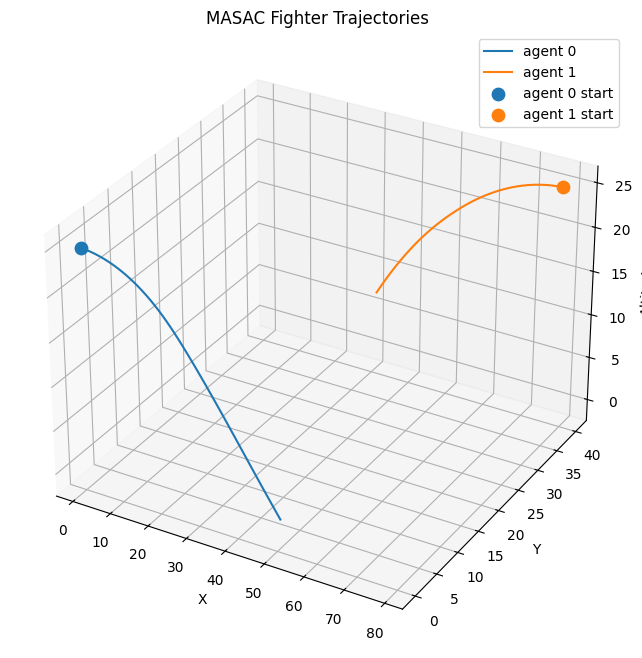

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from src.ma_fighter_env import MultiAgentFighterEnv
from src.masac import MASAC


env = MultiAgentFighterEnv()

agent = MASAC(
    n_agents=env.n_agents,
    obs_dim=env.obs_dim,
    act_dim=env.act_dim,
    device=device,
)

agent.load("models/masac_fighter.pt")

obs = env.reset()

traj0 = []
traj1 = []
energy0 = []
energy1 = []
dists = []

for _ in range(env.max_steps):
    actions = agent.act(obs, deterministic=True)
    obs, rewards, done, info = env.step(actions)

    traj0.append(env.pos[0].copy())
    traj1.append(env.pos[1].copy())
    energy0.append(info["energy_0"])
    energy1.append(info["energy_1"])
    dists.append(info["dist"])

    if done:
        break

traj0 = np.array(traj0)
traj1 = np.array(traj1)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(traj0[:, 0], traj0[:, 1], traj0[:, 2], label="agent 0")
ax.plot(traj1[:, 0], traj1[:, 1], traj1[:, 2], label="agent 1")

ax.scatter(traj0[0, 0], traj0[0, 1], traj0[0, 2], s=80, label="agent 0 start")
ax.scatter(traj1[0, 0], traj1[0, 1], traj1[0, 2], s=80, label="agent 1 start")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Altitude")
ax.set_title("MASAC Fighter Trajectories")
ax.legend()

plt.show()

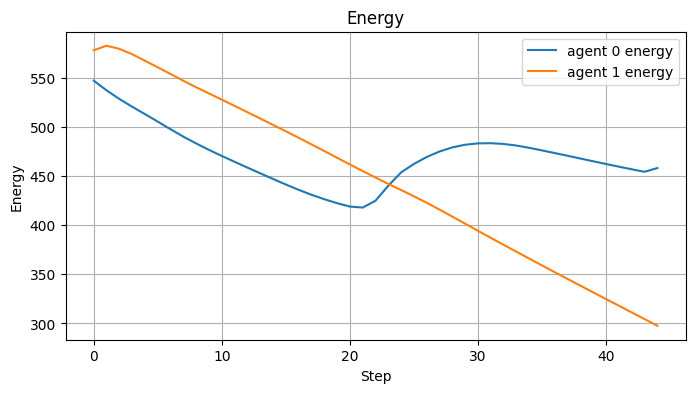

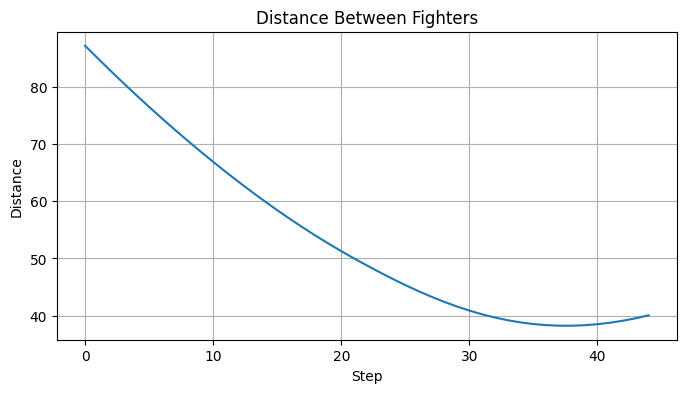

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(energy0, label="agent 0 energy")
plt.plot(energy1, label="agent 1 energy")
plt.title("Energy")
plt.xlabel("Step")
plt.ylabel("Energy")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(dists)
plt.title("Distance Between Fighters")
plt.xlabel("Step")
plt.ylabel("Distance")
plt.grid(True)
plt.show()